## This is the softmax workbook for ECE C147/C247 Assignment #2

Please follow the notebook linearly to implement a softmax classifier.

Please print out the workbook entirely when completed.

The goal of this workbook is to give you experience with training a softmax classifier.

In [1]:
import random
import numpy as np
from utils.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the linear classifier. These are the same steps as we used for the
    SVM, but condensed to a single function.  
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cifar-10-batches-py' # You need to update this line
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]
    
    # Preprocessing: reshape the image data into rows
    X_train = np.reshape(X_train, (X_train.shape[0], -1))
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))
    
    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image
    
    # add bias dimension and transform into columns
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])
    
    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev


# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('dev data shape: ', X_dev.shape)
print('dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3073)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3073)
Test labels shape:  (1000,)
dev data shape:  (500, 3073)
dev labels shape:  (500,)


## Training a softmax classifier.

The following cells will take you through building a softmax classifier.  You will implement its loss function, then subsequently train it with gradient descent.  Finally, you will choose the learning rate of gradient descent to optimize its classification performance.

In [3]:
from nndl import Softmax

In [4]:
# Declare an instance of the Softmax class.  
# Weights are initialized to a random value.
# Note, to keep people's first solutions consistent, we are going to use a random seed.

np.random.seed(1)

num_classes = len(np.unique(y_train))
num_features = X_train.shape[1]

softmax = Softmax(dims=[num_classes, num_features])

#### Softmax loss

In [5]:
## Implement the loss function of the softmax using a for loop over
#  the number of examples

loss = softmax.loss(X_train, y_train)

In [6]:
print(loss)

2.3277607028048757


## Question: 

You'll notice the loss returned by the softmax is about 2.3 (if implemented correctly).  Why does this make sense?

Hint: Connect to probability.

## Answer:

At initialization, the weights are set to small random values, resulting in scores close to zero. Consequently, the exponential of these scores is approximately 1. Since there are 10 classes in the CIFAR-10 dataset, the normalization term (sum of exponentials) is approximately 10. This leads to a probability distribution where each class has a probability of roughly $1/10$ or $0.1$. The cross-entropy loss is calculated as $-\ln(probability)$, so $-\ln(0.1) = \ln(10) \approx 2.3$.

#### Softmax gradient

In [7]:
## Calculate the gradient of the softmax loss in the Softmax class.
# For convenience, we'll write one function that computes the loss
#   and gradient together, softmax.loss_and_grad(X, y)
# You may copy and paste your loss code from softmax.loss() here, and then
#   use the appropriate intermediate values to calculate the gradient.

loss, grad = softmax.loss_and_grad(X_dev,y_dev)

# Compare your gradient to a gradient check we wrote. 
# You should see relative gradient errors on the order of 1e-07 or less if you implemented the gradient correctly.
softmax.grad_check_sparse(X_dev, y_dev, grad)

numerical: -0.060115 analytic: -0.060115, relative error: 4.641954e-07
numerical: 0.426604 analytic: 0.426604, relative error: 2.760104e-08
numerical: -0.321928 analytic: -0.321928, relative error: 1.605465e-08
numerical: 1.928266 analytic: 1.928266, relative error: 2.682734e-10
numerical: 1.739934 analytic: 1.739934, relative error: 2.684533e-08
numerical: 2.153248 analytic: 2.153248, relative error: 4.933154e-09
numerical: 0.529605 analytic: 0.529605, relative error: 4.501774e-08
numerical: -0.738285 analytic: -0.738285, relative error: 4.895991e-09
numerical: 1.596614 analytic: 1.596614, relative error: 6.239973e-09
numerical: -3.138518 analytic: -3.138519, relative error: 1.742244e-08


## A vectorized version of Softmax

To speed things up, we will vectorize the loss and gradient calculations.  This will be helpful for stochastic gradient descent.

In [8]:
import time

In [9]:
## Implement softmax.fast_loss_and_grad which calculates the loss and gradient
#    WITHOUT using any for loops.  

# Standard loss and gradient
tic = time.time()
loss, grad = softmax.loss_and_grad(X_dev, y_dev)
toc = time.time()
print('Normal loss / grad_norm: {} / {} computed in {}s'.format(loss, np.linalg.norm(grad, 'fro'), toc - tic))

tic = time.time()
loss_vectorized, grad_vectorized = softmax.fast_loss_and_grad(X_dev, y_dev)
toc = time.time()
print('Vectorized loss / grad: {} / {} computed in {}s'.format(loss_vectorized, np.linalg.norm(grad_vectorized, 'fro'), toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference in loss / grad: {} /{} '.format(loss - loss_vectorized, np.linalg.norm(grad - grad_vectorized)))

# You should notice a speedup with the same output.

Normal loss / grad_norm: 2.3259906233898517 / 315.69370372333213 computed in 0.03464198112487793s
Vectorized loss / grad: 2.3259906233898517 / 315.69370372333213 computed in 0.013659000396728516s
difference in loss / grad: 0.0 /2.090770683360497e-13 


## Stochastic gradient descent

We now implement stochastic gradient descent.  This uses the same principles of gradient descent we discussed in class, however, it calculates the gradient by only using examples from a subset of the training set (so each gradient calculation is faster).

iteration 0 / 1500: loss 2.3365926606637544
iteration 100 / 1500: loss 2.0557222613850827
iteration 200 / 1500: loss 2.0357745120662813
iteration 300 / 1500: loss 1.9813348165609888
iteration 400 / 1500: loss 1.9583142443981612
iteration 500 / 1500: loss 1.8622653073541355
iteration 600 / 1500: loss 1.8532611454359382
iteration 700 / 1500: loss 1.835306222372583
iteration 800 / 1500: loss 1.829389246882764
iteration 900 / 1500: loss 1.8992158530357484
iteration 1000 / 1500: loss 1.97835035402523
iteration 1100 / 1500: loss 1.8470797913532633
iteration 1200 / 1500: loss 1.8411450268664082
iteration 1300 / 1500: loss 1.7910402495792102
iteration 1400 / 1500: loss 1.8705803029382257
That took 6.007515907287598s


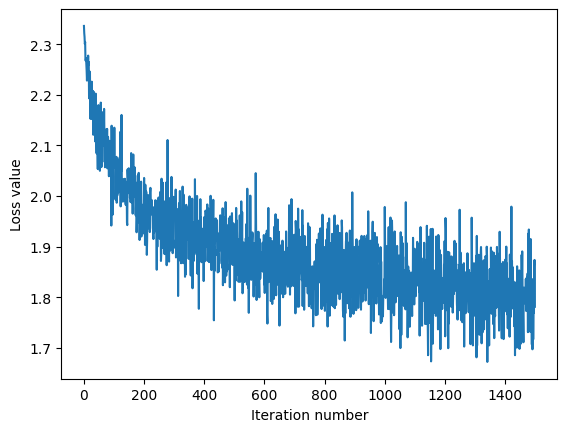

In [10]:
# Implement softmax.train() by filling in the code to extract a batch of data
# and perform the gradient step.
import time


tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took {}s'.format(toc - tic))

plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

### Evaluate the performance of the trained softmax classifier on the validation data.

In [11]:
## Implement softmax.predict() and use it to compute the training and testing error.

y_train_pred = softmax.predict(X_train)
print('training accuracy: {}'.format(np.mean(np.equal(y_train,y_train_pred), )))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: {}'.format(np.mean(np.equal(y_val, y_val_pred)), ))

training accuracy: 0.3811428571428571
validation accuracy: 0.398


## Optimize the softmax classifier

In [12]:
np.finfo(float).eps

2.220446049250313e-16

In [14]:
# ================================================================ #
# YOUR CODE HERE:
#   Train the Softmax classifier with different learning rates and 
#     evaluate on the validation data.
#   Report:
#     - The best learning rate of the ones you tested, determined by best validation accuracy.  
#     - The best validation accuracy.
#     - Select the model that achieved the best validation accuracy and report
#       its accuracy on the test set.
# ================================================================ #

learning_rates = [1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5]
best_val = -1
best_softmax = None
best_lr = None

results = {}

for lr in learning_rates:
    # Initialize a new Softmax classifier
    softmax = Softmax(dims=[num_classes, num_features])
    
    # Train the classifier
    # Using verbose=False to keep the output clean
    loss_hist = softmax.train(X_train, y_train, learning_rate=lr, num_iters=1500, verbose=False)
    
    # Predict on validation set
    y_val_pred = softmax.predict(X_val)
    val_acc = np.mean(np.equal(y_val, y_val_pred))
    
    results[lr] = val_acc
    print('lr %e val accuracy: %f' % (lr, val_acc))
    
    # Track the best model
    if val_acc > best_val:
        best_val = val_acc
        best_softmax = softmax
        best_lr = lr

print('\nBest validation accuracy achieved: %f' % best_val)
print('Best learning rate: %e' % best_lr)

# Evaluate on test set with the best model
y_test_pred = best_softmax.predict(X_test)
test_acc = np.mean(np.equal(y_test, y_test_pred))
print('Test accuracy: %f' % test_acc)

# ================================================================ #
# END YOUR CODE HERE
# ================================================================ #


lr 1.000000e-08 val accuracy: 0.293000
lr 5.000000e-08 val accuracy: 0.366000
lr 1.000000e-07 val accuracy: 0.395000
lr 5.000000e-07 val accuracy: 0.406000
lr 1.000000e-06 val accuracy: 0.413000
lr 5.000000e-06 val accuracy: 0.391000
lr 1.000000e-05 val accuracy: 0.338000

Best validation accuracy achieved: 0.413000
Best learning rate: 1.000000e-06
Test accuracy: 0.404000
